# Data Loading

In [35]:
import pandas as pd

data = pd.read_csv("predictions.csv", index_col = 0)
data.rename(columns={"pIC50": "real pIC50", "y_pred": "predicted pIC50"}, inplace=True)
data = data[["target_organism", "real pIC50", "predicted pIC50"]]
data.head()

,target_organism,real pIC50,predicted pIC50
3218,Salmonella enterica subsp. enterica serovar Ty...,1.501689,1.703981
9448,Staphylococcus aureus,1.966172,2.705194
2491,Raoultella planticola,2.958607,3.283466
319,Salmonella enterica subsp. enterica serovar Ty...,1.478862,1.668464
508,Staphylococcus aureus,1.271646,1.409023


# Prediction Analysis

## Metrics

In [43]:
y_real = data["real pIC50"]
y_pred = data["predicted pIC50"]

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
print("R² score: ", r2_score(y_real, y_pred))
print("MAE: ", mean_absolute_error(y_real, y_pred))
print("MSE: ", mean_squared_error(y_real, y_pred))
print("RMSE:", mean_squared_error(y_real, y_pred)**0.5)

R² score:  0.6103764469440591
MAE:  0.320953879556634
MSE:  0.19206650137389528
RMSE: 0.4382539233981771


# Graph

Text(0, 0.5, 'predicted pIC50')

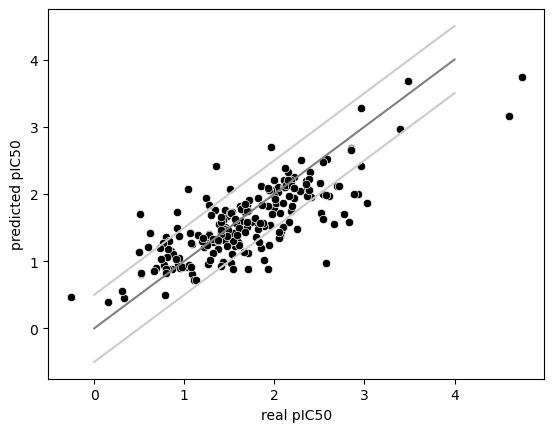

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x = [0,4], y=[0,4], color="gray")
sns.lineplot(x = [0,4], y=[0.5, 4.5], color="0.8")
sns.lineplot(x = [0,4], y=[-0.5, 3.5], color="0.8")
sns.scatterplot(x = y_real, y= y_pred, color="black")
plt.xlabel('real pIC50')
plt.ylabel('predicted pIC50')

In [42]:
import numpy as np
sum((y_real - y_pred) > 0.5) / len(y_real)

0.15813953488372093

<Axes: ylabel='Count'>

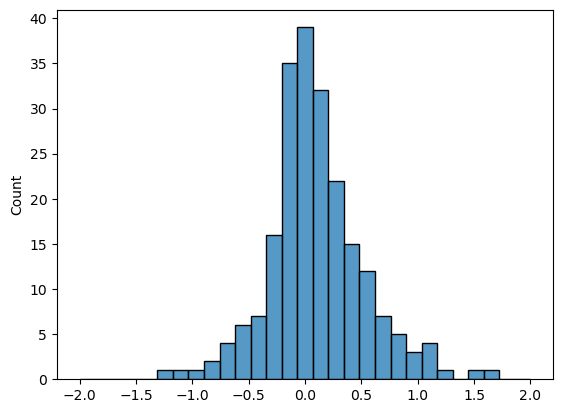

In [32]:
sns.histplot((y_real-y_pred), bins=29, binrange=(-2, 2))

## RESULTS BY SPECIES

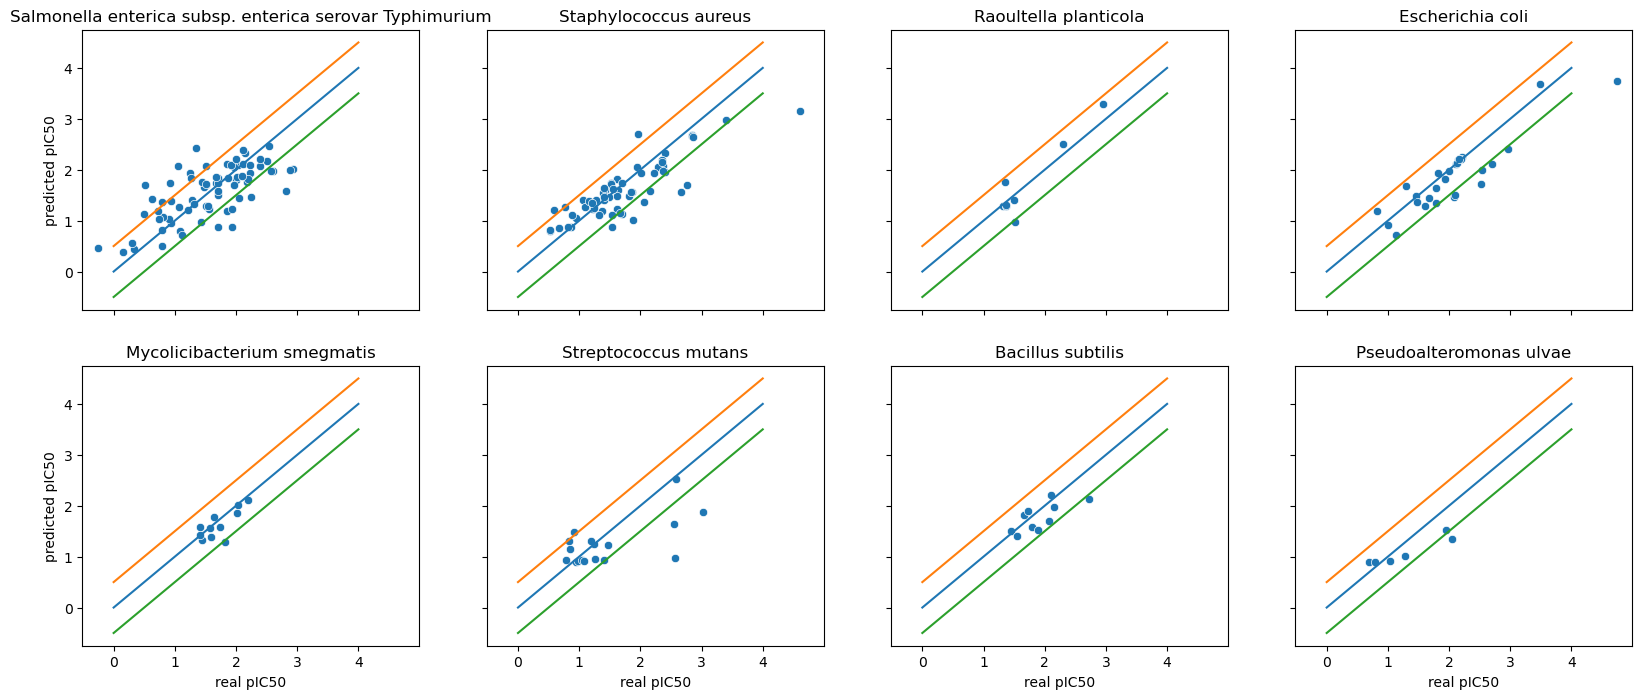

In [33]:
fig, axes = plt.subplots(2, 4, sharex="all", sharey="all", figsize = (20, 8))
for i, specie in enumerate(data.target_organism.unique()):
    ax = axes[i//4][i%4]
    sns.scatterplot(data[data.target_organism.eq(specie)], x="real pIC50", y="predicted pIC50", ax=ax)
    sns.lineplot(x = [0,4], y=[0,4], ax=ax)
    sns.lineplot(x = [0,4], y=[0.5, 4.5], ax=ax)
    sns.lineplot(x = [0,4], y=[-0.5, 3.5], ax=ax)
    ax.set_title(specie)

In [55]:
from collections import defaultdict

metrics = defaultdict(dict)

for specie in data.target_organism.unique():
    subdata = data[data.target_organism.eq(specie)]
    y = subdata["real pIC50"]
    y_pred = subdata["predicted pIC50"]
    metrics["R2"][specie] = r2_score(y, y_pred)
    metrics["MAE"][specie] =  mean_absolute_error(y, y_pred)
    metrics["RMSE"][specie] =  mean_squared_error(y, y_pred)**0.5

metrics = pd.DataFrame(metrics)

metrics.round(3)

,R2,MAE,RMSE
Salmonella enterica subsp. enterica serovar Typhimurium,0.479,0.382,0.492
Staphylococcus aureus,0.679,0.300,0.415
Raoultella planticola,0.741,0.222,0.284
Escherichia coli,0.741,0.290,0.396
Mycolicibacterium smegmatis,0.381,0.148,0.205
Streptococcus mutans,0.327,0.397,0.584
Bacillus subtilis,0.358,0.236,0.281
Pseudoalteromonas ulvae,0.517,0.302,0.368


In [50]:
for x in data.target_organism.value_counts().items():
    print(x)

('Salmonella enterica subsp. enterica serovar Typhimurium', 74)
('Staphylococcus aureus', 62)
('Escherichia coli', 27)
('Streptococcus mutans', 17)
('Mycolicibacterium smegmatis', 11)
('Bacillus subtilis', 10)
('Raoultella planticola', 8)
('Pseudoalteromonas ulvae', 6)
